# Local CPU/JAX version

This notebook is derived from `docs/examples/plane_wave_dataset.ipynb` for local learning. It skips the `!pip install vbeam` cell, forces the local editable environment, and reduces the scan size so CPU execution remains practical.


# Plane Wave Imaging (PWI)
Let's look at a PWI setup. Today we're beamforming one of the datasets from the PICMUS challenge _(Liebgott et al., ‘Plane-Wave Imaging Challenge in Medical Ultrasound’)_. Let's download it from [ustb.no](https://www.ustb.no/ustb-datasets/) and import it. We create a basic DAS beamformer using `get_das_beamformer` and JIT-compile it using JAX.

In [9]:
from pathlib import Path
import os
import site
import sys

os.environ.setdefault("PYTHONNOUSERSITE", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "friends" / ".matplotlib"))
try:
    user_site = Path(site.getusersitepackages()).resolve()
    sys.path = [p for p in sys.path if not p or Path(p).resolve() != user_site]
except Exception:
    pass

import jax
from pyuff_ustb import Uff

from vbeam.beamformers import get_das_beamformer
from vbeam.data_importers import import_pyuff
from vbeam.fastmath import backend_manager
from vbeam.util.download import cached_download

backend_manager.active_backend = "jax"

data_url = "http://www.ustb.no/datasets/PICMUS_carotid_cross.uff"
repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "vbeam").is_dir() and (p / "docs").is_dir()
)
data_dir = repo_root / "friends" / "data"
uff_path = data_dir / "www.ustb.no" / "datasets" / "PICMUS_carotid_cross.uff"
if not uff_path.exists():
    uff_path = Path(cached_download(data_url, local_dir=str(data_dir)))
uff = Uff(str(uff_path))
channel_data = uff.read("/channel_data")
scan = uff.read("/scan")

setup = import_pyuff(channel_data, scan, frames=0)
#setup.scan = setup.scan.resize(x=96*4, z=128*4)
beamformer = jax.jit(get_das_beamformer(setup))

print("Python:", sys.executable)
print("JAX devices:", jax.devices())
print("Setup sizes:", setup.size())
print("Setup spec:", setup.spec)


Python: C:\Users\Admin\.conda\envs\vbeam_jax_cpu\python.exe
JAX devices: [CpuDevice(id=0)]
Setup sizes: {'signal_time': 1536, 'receivers': 128, 'transmits': 75, 'points': 235683}
Setup spec: Spec({'signal': ['transmits', 'receivers', 'signal_time'], 'receiver': ['receivers'], 'point_position': ['points'], 'wave_data': ['transmits']})


## Plotting the Result
This is what the image looks like:

Result shape: (387, 609)
Result dtype: float32


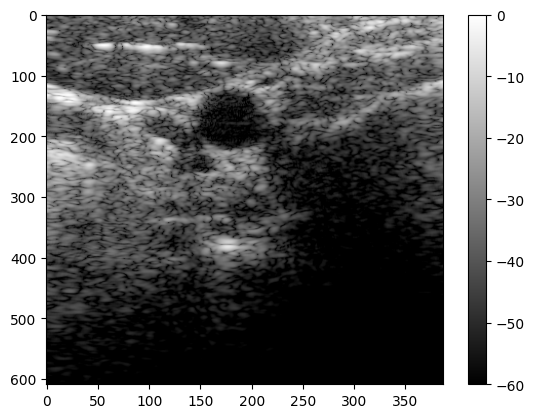

In [10]:
import matplotlib.pyplot as plt

result = beamformer(**setup.data).block_until_ready()
print("Result shape:", result.shape)
print("Result dtype:", result.dtype)
plt.imshow(result.T, aspect="auto", cmap="gray", vmin=-60)
plt.colorbar()


## How Fast is the Beamformer?
In the code cell below we are timing the beamformer using `%timeit`. There are 75 transmitted waves, 128 receiving elements, and the scan is 387x609 pixels. This amounts to 75x128x387x609 ≈ 2.3 billion points to be processed for one image. vbeam beamforms this image in 185 milliseconds, on average, on a Nvidia A100 GPU.

In [11]:
from math import prod

data = setup.data
%timeit -n 1 -r 1 beamformer(**data).block_until_ready()

num_points_to_be_processed = prod(setup.size(["transmits", "receivers", "points"]))
print(f"Processed points per call: {num_points_to_be_processed:.3e}")


3.06 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
Processed points per call: 2.263e+09


## How Fast is it to Beamform Just One Plane Wave?
This dataset has data for 75 transmitted plane waves, and vbeam uses 185 milliseconds to beamform them all. How fast is vbeam when it only has to beamform a single plane wave?

The cell below slices the data such that only the plane wave at index 37 in the data is included. We then beamform and time it again using `%timeit`. vbeam uses around 3.36 milliseconds to beamform a single plane wave for this setup, amounting to approximately 9 billion points per second. This is a lower number than in the previous example, likely due to not utilizing the GPU as efficiently.

One-transmit result shape: (384, 512)
75.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


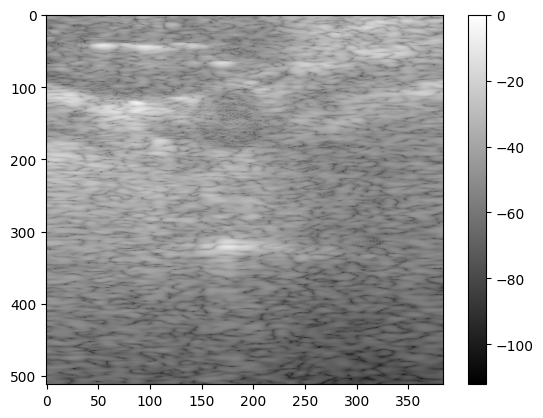

In [8]:
setup_1_transmit = setup.slice["transmits", 37]
beamformer_1_transmit = jax.jit(get_das_beamformer(setup_1_transmit))
result_1_transmit = beamformer_1_transmit(**setup_1_transmit.data).block_until_ready()
print("One-transmit result shape:", result_1_transmit.shape)
plt.imshow(result_1_transmit.T, aspect="auto", cmap="gray")
plt.colorbar()

data_1_transmit = setup_1_transmit.data
%timeit -n 1 -r 1 beamformer_1_transmit(**data_1_transmit).block_until_ready()
